In [1]:
from util import *

In [2]:
gdp = load_gdp()

In [3]:
df = make_joined_df(gdp=gdp)

We want to look at the association between gdp and enrollment. We could look at enrollment several ways; however, since gdp is a national measure, I'm choosing to look at enrollment as a national gross for the sake of comparison.

In [5]:
 # mean gdp within a country and year should just return gdp
nationalized_df = df.groupby(['region', 'country', 'year']).agg({'students5_estimated': 'sum', 'gdp': 'mean'}) \
                    .reset_index() \
                    .rename(columns={'students5_estimated': 'national_enrollment'}) \
                    .dropna() # already reduced columns to the essentials, drop any with missing data
nationalized_df.head(5)

,region,country,year,national_enrollment,gdp
0,east asia and pacific,australia,1960.0,75865.0,1.860679e+10
1,east asia and pacific,australia,1965.0,126957.0,2.597715e+10
2,east asia and pacific,australia,1970.0,184147.0,4.133722e+10
3,east asia and pacific,australia,1975.0,237631.0,9.733306e+10
4,east asia and pacific,australia,1980.0,268443.0,1.500000e+11


As a general rule, Pearson's R only applies to linear relationships. It's highly unlikely that gdp and enrollment are linearly related, but plot it to verify.

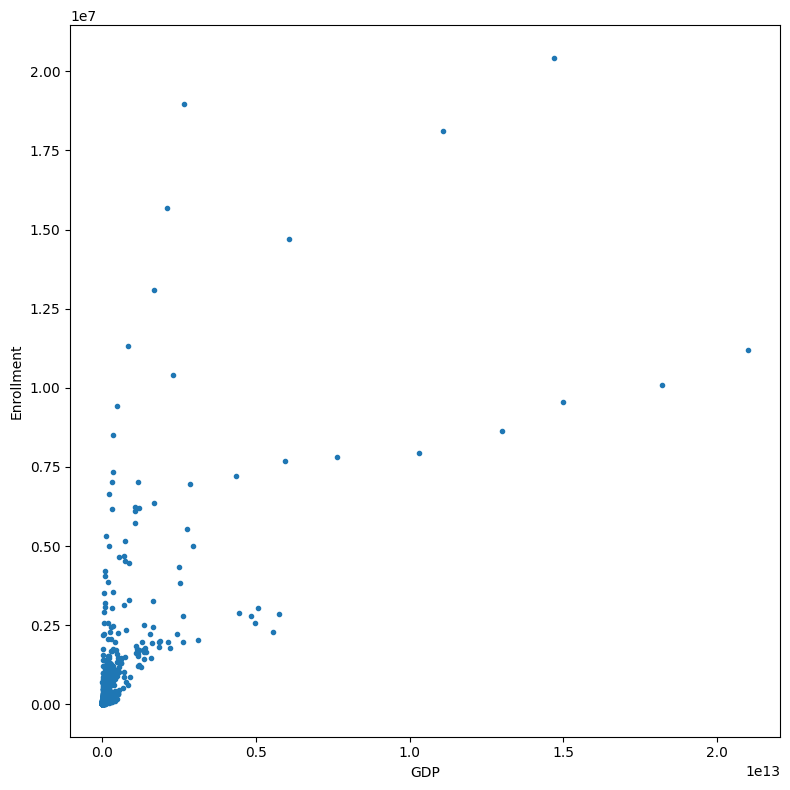

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

x, y = nationalized_df['gdp'], nationalized_df['national_enrollment']
           
ax.scatter(x, y, marker='.')
    
ax.set_xlabel('GDP')
ax.set_ylabel('Enrollment')
plt.tight_layout()
plt.show()

Yeah, I'd say they're not _generally_ linearly related, but there are some interesting subgroups within that plot that might indicate a linear relationship. Let's do a cursory examination of the likely subgroups of interest: region and country.

In [7]:
# we'll use these a few times
from matplotlib import colormaps

cmap = colormaps.get_cmap('plasma')
regions = nationalized_df['region'].unique()
n_r = len(regions)

color_map = {
    name: cmap(i / (n_r)) # only using n_r -1 colors, but the last will be low-contrast yellow
    for i, name in enumerate(regions)
}

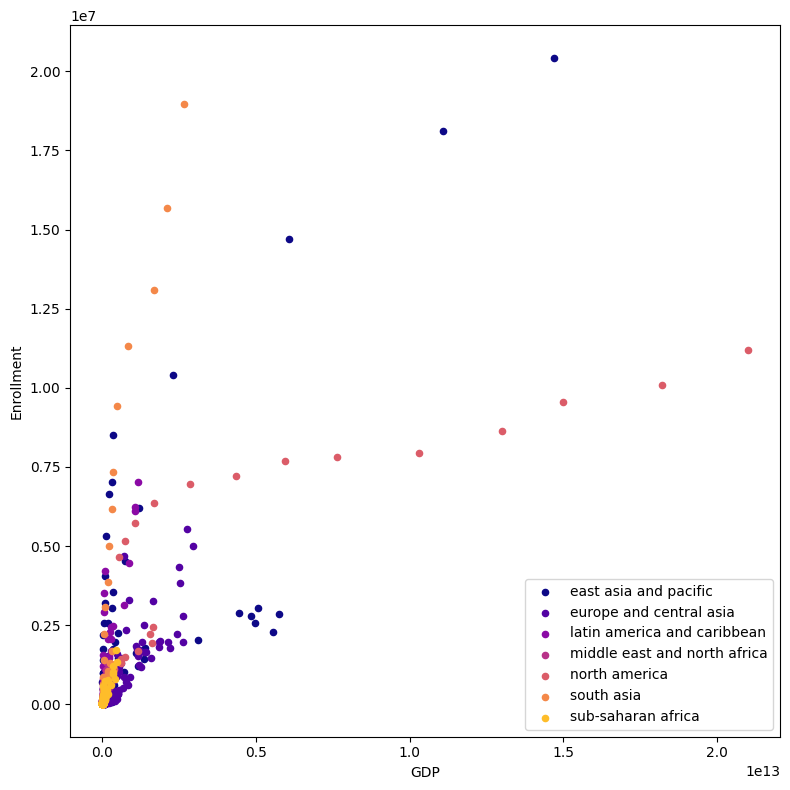

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

for region, data in nationalized_df.groupby('region'):
    data.plot(kind='scatter', x='gdp', y='national_enrollment', label=region, color=color_map[region], ax=ax)
    
ax.set_xlabel('GDP')
ax.set_ylabel('Enrollment')
plt.tight_layout()
plt.show()

It certainly looks as though gdp may relate to enrollment _at least_ monotonically when we account for region. That would make Spearman's rho an appropriate measure. A closer look, incorporating country to eliminate that source of variance.

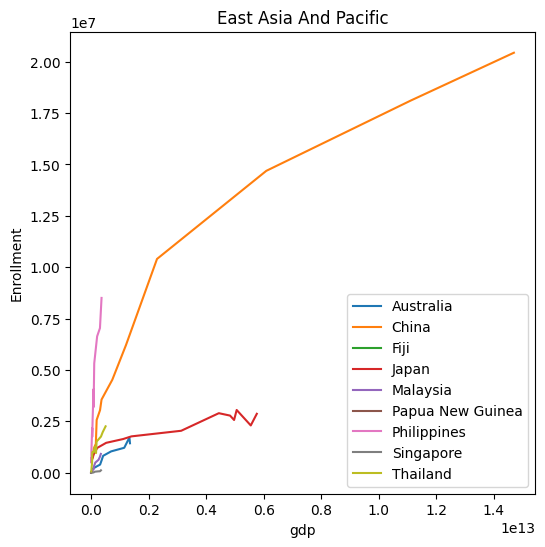

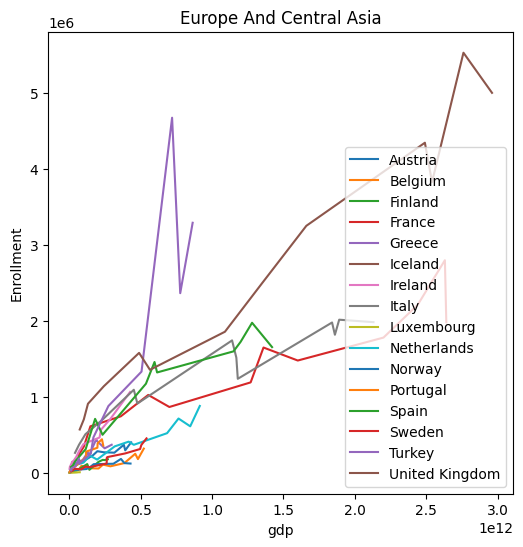

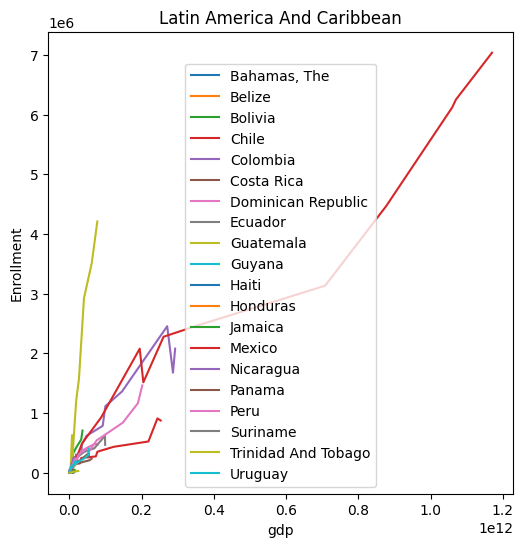

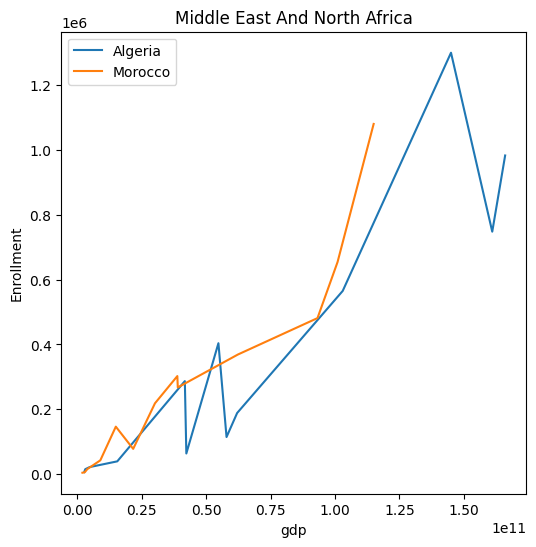

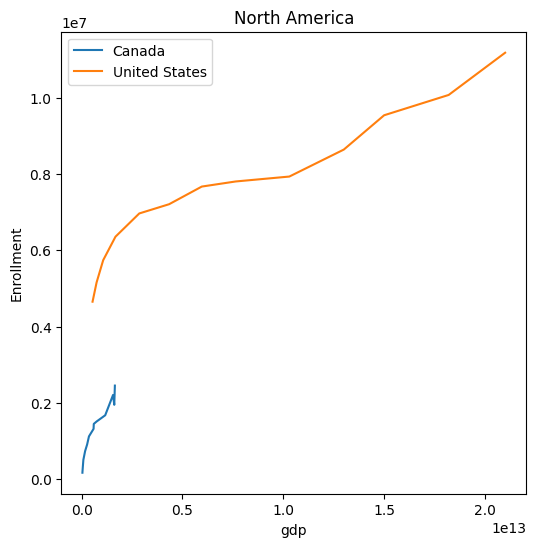

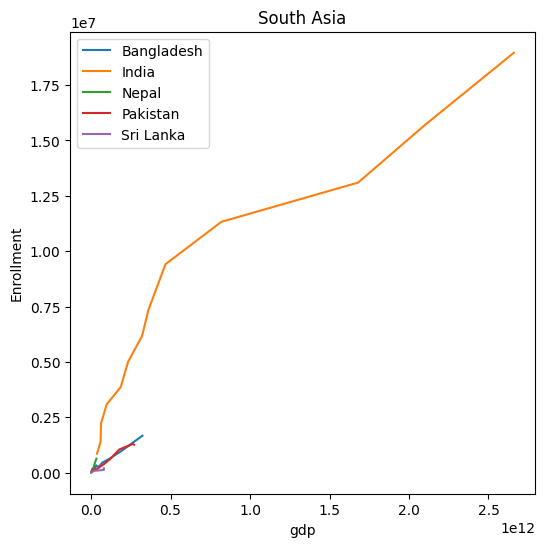

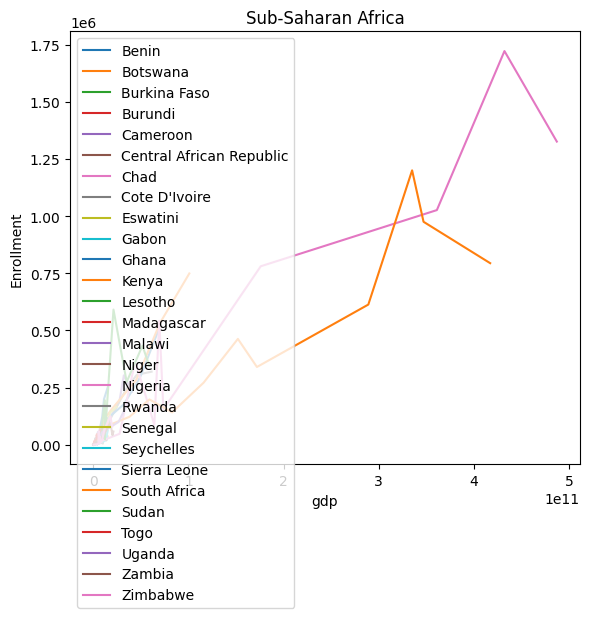

In [13]:

for region, data in nationalized_df.sort_values('gdp').groupby('region'): # appropriate to sort by gdp since we're using that as the independent variable
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlabel('GDP')
    ax.set_ylabel('Enrollment')
    ax.set_title(f'{region.title()}')

    for country, c_data in data.groupby('country'): # pick each country within each region
        c_data.plot(kind='line', x='gdp', y='national_enrollment', label=country.title(), ax=ax)
   

plt.tight_layout()
plt.legend(loc='upper left')
plt.show()

It's fair to say there is a _mostly_ positive association between GDP and national enrollment and _mostly_ monotonic, though linearity seems to be ruled out. As an aside, some of the larger countries (or higher gdp countries) dominate these graphs. Some form of norming would probably be appropriate if we were building out an ML model, otherwise certain features could dominate the loss function. Anyway, let's try Spearman's rho to confirm monotonicity.

In [14]:
from scipy.stats import spearmanrho

# first look at it in general
spearmanrho(x=nationalized_df[['gdp']], y=nationalized_df[['national_enrollment']])

SignificanceResult(statistic=array([0.90113026]), pvalue=array([0.]))

OK, pretty convincing, no need to drill down through the categorical variables. There isn't convincing evidence of a linear relationship _in general_. I'm not going to spend the time performing linear regression and making a QQ plot of residuals, or performing further testing, the visual observation has me convinced. The evidence suggests there is a monotonic relationship between the two, which is helpful, but it's more complex than a simple linear relationship.

Theoretically, it's worth examining QQ plots of both variables and, if warranted, calculating polychoric correlation, but the Spearman's rho is sufficiently to demonstrate some degree of (monotonic) correlated behavior.

Anyway, let's examine non-linear correlation measures. Distance correlation can detect both linear and nonlinear associations, the latter of which is crucial here.

In [ ]:
from dcor import distance_correlation

print(distance_correlation(x,y))

0.7430042404925692


That pretty much confirms these are not independent. We probably could have assumed as much, but it's good to check. We can take one further step and look at a single latent variable available in the data: time. Let's compare the mutual information for `year` and `gdp` for predicting `national_enrollment`. Hypothetically, if we wanted to build an ML model to predict enrollment, we might use the year and/or the gdp as features. Which of these has the most relevant information about enrollment? What can we say about them, comparing their internal entropy to their shared relationship with the target variable (enrollment)?

In [ ]:
from sklearn.feature_selection import mutual_info_regression

m_i = mutual_info_regression(X=nationalized_df[['year', 'gdp']], y=nationalized_df['national_enrollment'])
print(m_i)
print(f'information ratio: {m_i[1]/m_i[0]}')

[0.14880462 0.82519524]
information ratio: 5.545494655543261


That drives home the point that national enrollment isn't simply driven by _time_. There is a stronger connection to gdp than the simple passing of the years. Now, we could have gone further by looking at every available variable, which would have required discretizing the continuous variables to allow us to compare them to, say, the categorical variables. There is a whole process one might undertake in planning a predictive model. However, at this stage, I would feel comfortable telling a decision maker that there is a strong, positive, nonlinear, association between GDP and total national university enrollment.

We haven't looked at any latent factors between the two (for example, it seems plausible that underlying population growth is a driver of both, but we haven't looked at that). It might be valuable to look at partial correlations after controlling for some of these variables, but at this point we've established a useful connection and wouldn't delve too much further into the theoretical modeling of specific variables; instead, building some form of ML regressor would probably be the goal, and we could examine the impact of different variables during feature selection.